In [1]:
from TS_formulation import * 
from constraint_equations import *
from functools import partial

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

color = {'blue': '#377eb8',
         'orange': '#ff7f00', 
         'green': '#4daf4a',
        'pink':'#f781bf', 
        'brown':'#a65628',
         'purple': '#984ea3',
         'gray': '#999999',
          'red': '#e41a1c', 
          'yellow':'#dede00'}

Fuel Fractions:
strike                   : 0.2937
strike_mid_mission       : 0.1637
strike_end_mission       : 0.2739
combat                   : 0.2805
combat_mid_mission       : 0.1343
combat_end_mission       : 0.2765


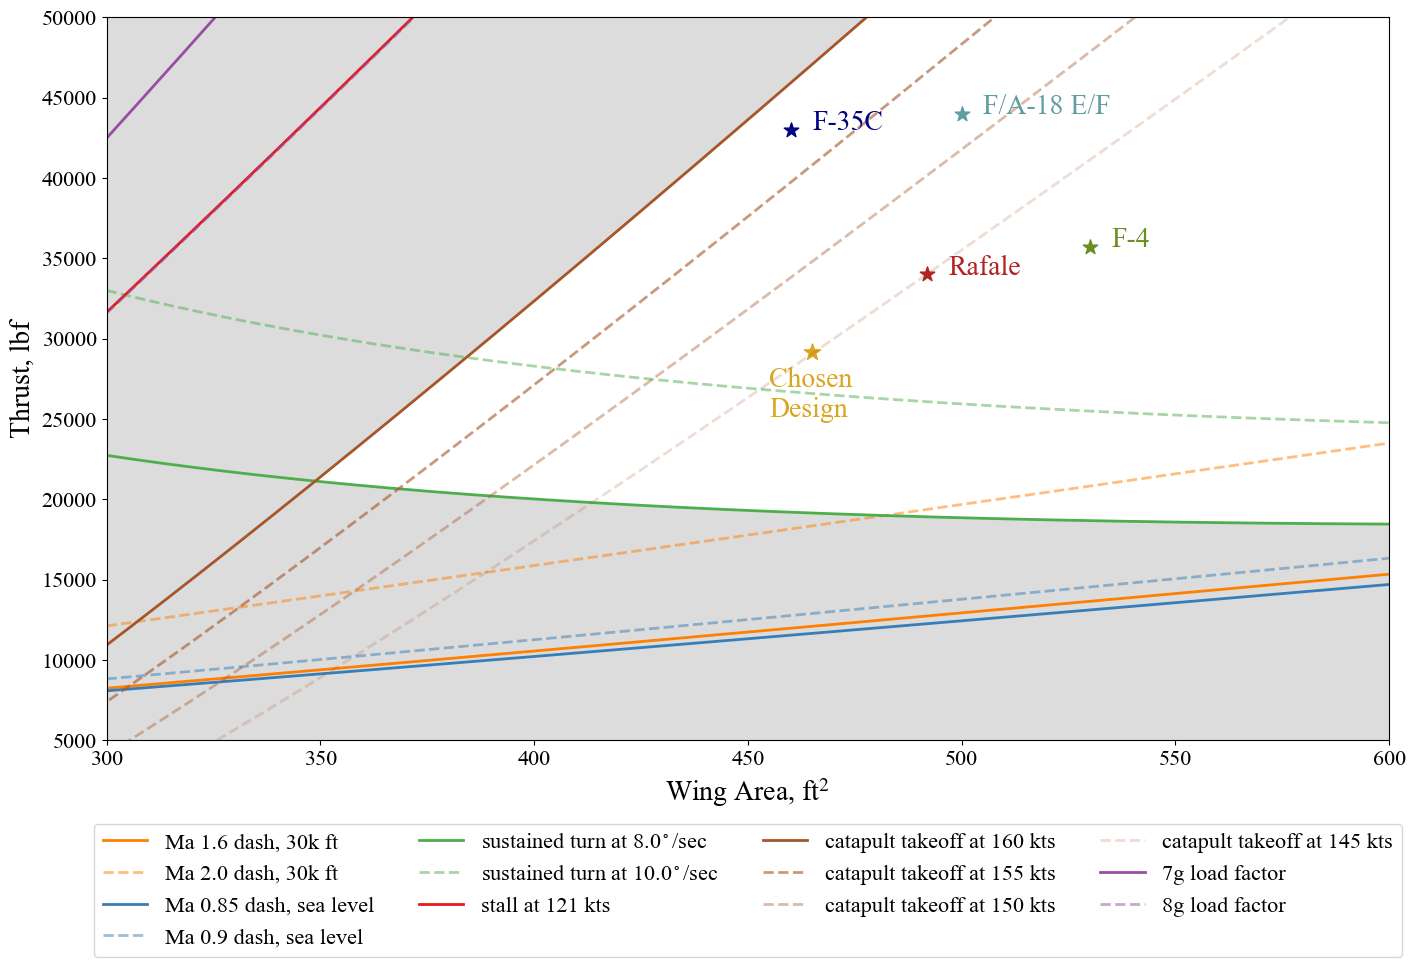

In [11]:
# plt.figure(figsize=(17, 8.5))
plt.figure(figsize=(15, 10))

S_guess = np.linspace(300, 600, 400)

# Ma 1.6 dash, 30k ft
TS_line(S_guess, W_guess=50000, T_0=44000, 
        segment_function=partial(dash, Ma=1.6, alt=30000), mission='combat',
        plot_styling={'label': 'Ma 1.6 dash, 30k ft','linestyle': '-', 'color':color['orange'], 'linewidth':2},
        fill=True)
#Ma 2.0 dash, 30k ft
TS_line(S_guess, W_guess=50000, T_0=44000, 
        segment_function=partial(dash, Ma=2.0, alt=30000), mission='combat',
        plot_styling={'label': 'Ma 2.0 dash, 30k ft','linestyle': '--', 'color':color['orange'], 'alpha':0.5, 'linewidth':2})

#Ma 0.85 dash, sea level
TS_line(S_guess, W_guess=50000, T_0=44000, 
        segment_function=partial(dash, Ma=0.85, alt=0), mission='strike',
        plot_styling={'label': 'Ma 0.85 dash, sea level','linestyle': '-', 'color':color['blue'], 'linewidth':2},
        fill=True)
#Ma 0.9 dash, sea level
TS_line(S_guess, W_guess=50000, T_0=44000, 
        segment_function=partial(dash, Ma=0.9, alt=0), mission='strike',
        plot_styling={'label': 'Ma 0.9 dash, sea level','linestyle': '--', 'color':color['blue'], 'alpha': 0.5, 'linewidth':2})
# sustained turn 8 deg/sec
TS_line(S_guess, W_guess=50000, T_0=44000, 
        segment_function=partial(sustained_turn, Ma=0.85, alt=20000, deg=8.0), mission='combat',
        plot_styling={'label': r'sustained turn at 8.0$^\circ$/sec','linestyle': '-', 'color':color['green'], 'linewidth':2},
        fill=True)
# sustained turn 10 deg/sec
TS_line(S_guess, W_guess=50000, T_0=44000, 
        segment_function=partial(sustained_turn, Ma=0.85, alt=20000, deg=10.0), mission='combat',
        plot_styling={'label': r'sustained turn at 10.0$^\circ$/sec','linestyle': '--', 'color': color['green'], 'alpha':0.5, 'linewidth':2})


# TS_line(S_guess, W_guess=50000, T_0=44000,
#         segment_function=partial(service_ceiling, RoC=500), mission='strike',
#         plot_styling={'label': "service ceiling 50k ft, 500 ft/min", 'linestyle':'-', 'color': color['gray'], 'linewidth':2},
#         fill=True)

T_sweep = np.linspace(1000, 80000, 400)
# stall
V_engage = 140.0
V_approach = V_engage / 1.05
V_stall = V_approach / 1.10

# stall
WS_line(W_guess=50000, T_0=T_sweep, mission='strike',
        segment_function=stall(V_stall=V_stall, alt=0),
        plot_styling={'label': f'stall at {V_stall:.0f} kts', 'linestyle': '-', 'color': color['red'], 'linewidth':2})

# takeoff at 160 kts
V_end = 160.0

WS_line(W_guess=50000, T_0=T_sweep, mission='strike',
        segment_function=takeoff(V_end), 
        weight_fraction=partial(weight_fraction, fuel_fraction=0),
        unloaded_weight=0,
        plot_styling={'label': f'catapult takeoff at {V_end:.0f} kts', 'linestyle': '-', 'color': color['brown'], 'linewidth':2 },
        fill=True)

WS_line(W_guess=50000, T_0=T_sweep, mission='strike',
        segment_function=takeoff(V_end-5), 
        weight_fraction=partial(weight_fraction, fuel_fraction=0),
        unloaded_weight=0,
        plot_styling={'label': f'catapult takeoff at {V_end-5:.0f} kts', 'linestyle': '--', 'color': color['brown'], 'linewidth':2,'alpha':0.6},
        fill=False)

WS_line(W_guess=50000, T_0=T_sweep, mission='strike',
        segment_function=takeoff(V_end-10), 
        weight_fraction=partial(weight_fraction, fuel_fraction=0),
        unloaded_weight=0,
        plot_styling={'label': f'catapult takeoff at {V_end-10:.0f} kts', 'linestyle': '--', 'color': color['brown'], 'linewidth':2,'alpha':0.4},
        fill=False)


WS_line(W_guess=50000, T_0=T_sweep, mission='strike',
        segment_function=takeoff(V_end-15), 
        weight_fraction=partial(weight_fraction, fuel_fraction=0),
        unloaded_weight=0,
        plot_styling={'label': f'catapult takeoff at {V_end-15:.0f} kts', 'linestyle': '--', 'color': color['brown'], 'linewidth':2,'alpha':0.2},
        fill=False)


# instantaneous load factor, usable (7g)
WS_line(W_guess=50000, T_0=T_sweep,
        segment_function=instant_load_factor(Ma=0.90, alt=20000, n=7), mission='strike',
        weight_fraction=partial(weight_fraction, fuel_fraction=0),
                plot_styling={'label': '7g load factor','linestyle': '-', 'color': color['purple'], 'linewidth':2}, fill=False)

#instantaneous load factor, usable (8g)
WS_line(W_guess=50000, T_0=T_sweep,
        segment_function=instant_load_factor(Ma=0.90, alt=20000, n=8), mission='strike',
        weight_fraction=partial(weight_fraction, fuel_fraction=0),
                plot_styling={'label': '8g load factor','linestyle': '--', 'color': color['purple'], 'linewidth':2, 'alpha':0.5}, fill=False)

plt.xlabel('Wing Area, ft$^2$', fontsize=20)
plt.ylabel('Thrust, lbf', fontsize=20)
# plt.title('T-S Diagram', fontsize=20)
plt.xlim([300, 600])
plt.xticks(fontsize=16)
plt.ylim([5000, 50000])
plt.yticks(fontsize=16)
ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
#plt.legend(bbox_to_anchor=(1, 1), loc='upper left', ncols=1, fontsize=16)
plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncols=4, fontsize=16)
plt.tight_layout()


### Plot Comparable Aircrafts
text_spacer = 5
plt.scatter(500, 44000, marker='*', color='cadetblue', s=120) # F/A-18 E/F
plt.scatter(460, 43000, marker='*', color='navy', s=120) # F-35C
plt.scatter(492, 34000, marker='*', color='firebrick', s=120) # Dassault Rafale
plt.scatter(530, 35690, marker='*', color='olivedrab', s=120) # F-4 
# # plt.scatter(551, 40400, marker='*', color='cadetblue') # Eurofighter Typhoon
plt.annotate("F/A-18 E/F", (500+text_spacer, 44000), fontsize=20, color='cadetblue') #F/A-18 E/F
plt.annotate("F-35C", (460+text_spacer, 43000), fontsize=20, color='navy') # F-35C
plt.annotate("Rafale", (492+text_spacer, 34000), fontsize=20, color='firebrick') # Dassault Rafale
plt.annotate("F-4", (530+text_spacer, 35690), fontsize=20, color='olivedrab') # F-4
# # plt.annotate("Eurofighter", (551+text_spacer, 40400), fontsize=10, color='cadetblue') # Eurofighter 
chosen_point = {'s': [465, 465], 't':[29160,  17800]}

plt.scatter(chosen_point['s'][0], chosen_point['t'][0], marker='*', s=150, color='goldenrod', label=f'chosen point (a/b, {chosen_point['t'][0]} lbf thrust)')
# plt.scatter(chosen_point['s'][1], chosen_point['t'][1], marker='*', s=80, color='slategray', alpha=0.5, label=f'chosen point (dry, {chosen_point['t'][1]} lbf thrust)')
W_chosen, _, _ = weight_convergence(50000, T_0 = chosen_point['t'][0], 
                                    S={'wing': chosen_point['s'][0], 'htail': 123.10441485216471, 'vtail': 107.19521577810403, 'fuse_wet': 702.3,}, 
                                    mission='strike')
# W_chosen2, _, _ = weight_convergence(50000, T_0 = chosen_point['t'][1], 
#                                     S={'wing': chosen_point['s'][1], 'htail': 78.41, 'vtail': 78.41, 'fuse_wet': 529.81}, 
#                                     mission='strike')
plt.annotate( "Chosen\nDesign",
#     f"MTOW:\n{W_chosen:.0f} lbs", 
    (chosen_point['s'][0]-10, chosen_point['t'][0]-4000), fontsize=20, color='goldenrod')

# plt.savefig('presentation_aid/fig0.svg', transparent=True)
plt.savefig("TS_diagram.pdf")

In [3]:
chosen_point = {'s': [465, 465], 't':[29160,  17800]}
W_chosen, _, _ = weight_convergence(50000, T_0 = chosen_point['t'][0], 
                                    S={'wing': chosen_point['s'][0], 'htail': 123.10441485216471, 'vtail': 107.19521577810403, 'fuse_wet': 702.3,}, 
                                    mission='strike')

49392.590961842085 27807.540528083242 14505.05043375884


In [4]:
W_chosen

np.float64(49392.590961842085)

In [9]:
29160/W_chosen

np.float64(0.5807330312870554)

In [8]:
W_chosen/625

np.float64(80.33984203825666)

In [ ]:
1*0.95*0.9

In [ ]:
1/1.05/1.10

In [ ]:
W_fixed_payload

In [ ]:
W_chosen

In [ ]:
W_chosen - W_fixed_payload['combat'] - 13923.216722889065

In [ ]:
W_chosen - W_fixed_payload['strike'] - 14424.998766143262

In [ ]:
from fuel_fraction import *
fuel_fraction


In [ ]:
fuel_fraction.items

In [ ]:
[fuel * W_chosen for _, fuel in fuel_fraction.items()]

In [ ]:
chosen_point = {'s': [465, 465], 't':[29160,  17800]}
text_spacer = 5
### Plot Comparable Aircrafts
plt.scatter(500, 44000, marker='*', color='goldenrod') # F/A-18 E/F
plt.scatter(460, 43000, marker='*', color='navy') # F-35C
plt.scatter(492, 34000, marker='*', color='firebrick') # Dassault Rafale
plt.scatter(530, 35690, marker='*', color='olivedrab') # F-4 
# plt.scatter(551, 40400, marker='*', color='cadetblue') # Eurofighter Typhoon
plt.annotate("F/A-18 E/F", (500+text_spacer, 44000), fontsize=12, color='goldenrod') #F/A-18 E/F
plt.annotate("F-35C", (460+text_spacer, 43000), fontsize=12, color='navy') # F-35C
plt.annotate("Rafale", (492+text_spacer, 34000), fontsize=12, color='firebrick') # Dassault Rafale
plt.annotate("F-4", (530+text_spacer, 35690), fontsize=12, color='olivedrab') # F-4
# plt.annotate("Eurofighter", (551+text_spacer, 40400), fontsize=10, color='cadetblue') # Eurofighter 


plt.scatter(chosen_point['s'][0], chosen_point['t'][0], marker='*', color='slategray', label=f'chosen point (a/b, {chosen_point['t'][0]} lbf thrust)')
plt.scatter(chosen_point['s'][1], chosen_point['t'][1], marker='*', color='slategray', alpha=0.5, label=f'chosen point (dry, {chosen_point['t'][1]} lbf thrust)')
W_chosen, _, _ = weight_convergence(50000, T_0 = chosen_point['t'][0], 
                                    S={'wing': chosen_point['s'][0], 'htail': 78.41, 'vtail': 78.41, 'fuse_wet': 529.81}, 
                                    mission='strike')
# W_chosen2, _, _ = weight_convergence(50000, T_0 = chosen_point['t'][1], 
#                                     S={'wing': chosen_point['s'][1], 'htail': 78.41, 'vtail': 78.41, 'fuse_wet': 529.81}, 
#                                     mission='strike')
plt.annotate(f"MTOW:\n{W_chosen:.0f} lbs", (chosen_point['s'][0]-10, chosen_point['t'][0]-4500), fontsize=12, color='slategray')
# plt.annotate(f"MTOW: {W_chosen2:.0f} lbs", (chosen_point['s'][1], chosen_point['t'][1]-4000), fontsize=10, color='slategray')

plt.xlabel('Wing Area, ft$^2$', fontsize=16)
plt.ylabel('Thrust, lbf', fontsize=16)
plt.title('T-S Diagram', fontsize=20)
plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncols=4, fontsize=14)
plt.xlim([300, 600])
plt.xticks(fontsize=14)
plt.ylim([5000, 50000])
plt.yticks(fontsize=14)
plt.tight_layout()


plt.savefig("TS_diagram.pdf")
plt.show()